<div style="text-align: right;">
Тищенко Кирилл АС-23-05 Вариант 2
</div>

# Лабортаторная работа № 1 "Статистический анализ одномерных выборок. Предварительный статистический анализ"

Импортируем библиотеки

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

Загружаем датасет из Excel-файла

In [110]:
file_name = "data1.xlsx"

df = pd.read_excel(
    file_name,
    sheet_name=1,
    usecols="A:G",
    header = None,
    engine="openpyxl"
)

print(df.head())

           0          1          2          3   4   5          6
0 -16.427992  10.337568  10.094972  12.235925  10  16  -2.336080
1 -29.368694  20.601542  15.573639  12.159321   6  15   5.041232
2  -6.561724   1.876631   2.625150  24.552468  10  14   6.987623
3   7.358867  17.243398  15.855155  12.348476   9  14   9.542421
4   6.692038 -23.179041  11.742064  19.597243   9  15  11.116361


## 1. Оценка числовых характеристик

In [25]:
results = []
confidence = 0.95

for col in df.columns:
    data = df[col].dropna()
    n = len(data)

    mean = data.mean()
    median = data.median()
    mode = data.mode().iloc[0] if not data.mode().empty else np.nan
    std = data.std(ddof=1)
    var = data.var(ddof=1)
    sem = stats.sem(data)
    skew = stats.skew(data)
    kurt = stats.kurtosis(data)
    min_val = data.min()
    max_val = data.max()
    data_range = max_val - min_val
    total_sum = data.sum()

    t_crit = stats.t.ppf((1 + confidence) / 2, df=n-1)
    margin = t_crit * sem
    ci_lower = mean - margin
    ci_upper = mean + margin

    results.append([
        n, mean, sem, median, mode, std, var,
        kurt, skew, data_range, min_val, max_val,
        total_sum, ci_lower, ci_upper
    ])

columns = [
    "N", "Среднее", "Стд. ошибка", "Медиана", "Мода",
    "Стд. откл.", "Дисперсия", "Эксцесс", "Асимметрия",
    "Размах", "Минимум", "Максимум", "Сумма",
    "CI 95% (ниж)", "CI 95% (верх)"
]

stats_table = pd.DataFrame(results, columns=columns, index=df.columns).style

stats_table

,N,Среднее,Стд. ошибка,Медиана,Мода,Стд. откл.,Дисперсия,Эксцесс,Асимметрия,Размах,Минимум,Максимум,Сумма,CI 95% (ниж),CI 95% (верх)
0,500,-10.356208,0.607520,-9.587024,-20.190313,13.584549,184.539975,-1.246367,-0.071625,45.765557,-33.870846,11.894711,-5178.103885,-11.549819,-9.162596
1,500,8.813767,0.819621,8.710024,-23.627036,18.327286,335.889412,0.287275,-0.038906,112.458074,-49.504520,62.953554,4406.883337,7.203433,10.424100
2,500,8.815445,0.599740,8.947190,8.427380,13.410601,179.844218,-0.229775,-0.043017,80.036116,-28.674916,51.361200,4407.722347,7.637117,9.993772
3,500,12.626233,0.312670,12.756511,14.506429,6.991504,48.881130,0.027581,0.152056,42.804531,-7.461513,35.343018,6313.116390,12.011922,13.240544
4,500,8.392000,0.072769,8.000000,9.000000,1.627154,2.647631,-0.343639,-0.188030,9.000000,3.000000,12.000000,4196.000000,8.249029,8.534971
5,500,12.114000,0.150650,12.000000,12.000000,3.368635,11.347699,0.354309,0.392514,23.000000,3.000000,26.000000,6057.000000,11.818014,12.409986
6,500,7.921503,0.171443,7.737115,6.583730,3.833575,14.696298,0.301399,0.016765,26.375637,-5.948884,20.426754,3960.751652,7.584665,8.258342


Исходя из оценки числовых характеристик можно попробовать оценить распределение:
1. Анализ эксцесса:
   - Выборка №1 имеет Эксцесс < -1.2
   - В оставшихся выборках абсолютное значение эксцесса не превышает 0.4
2. Сравнение среднего значения и медианного значения:
   - Выборка №1 демонстрирует разность значений примерно на 0.8
   - Разность значений в остальных выборка не превышает 0.4 (худший случай)

**Исходя из этих наблюдений, можно предположить, что выборка №1 подчиняется законам равномерного распределения, а остальные - законам нормального распределения**

## 2. Графический анализ

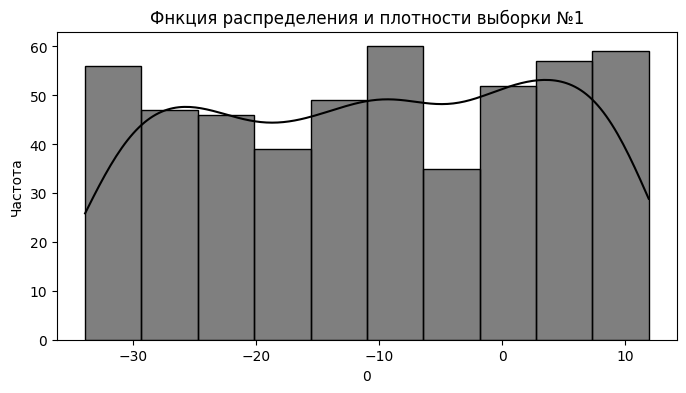

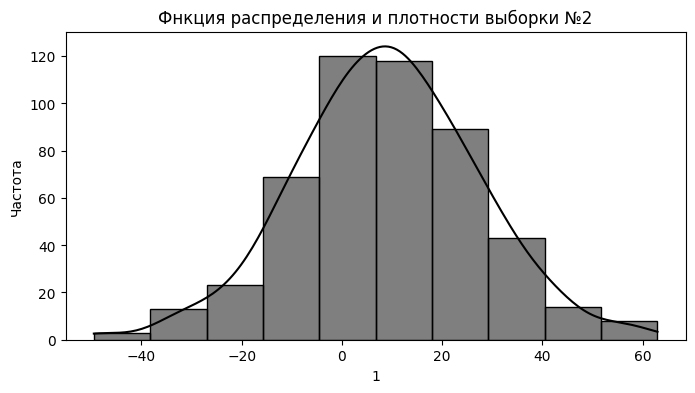

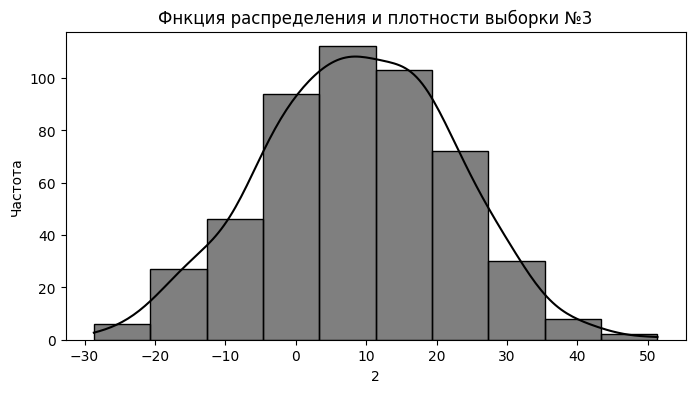

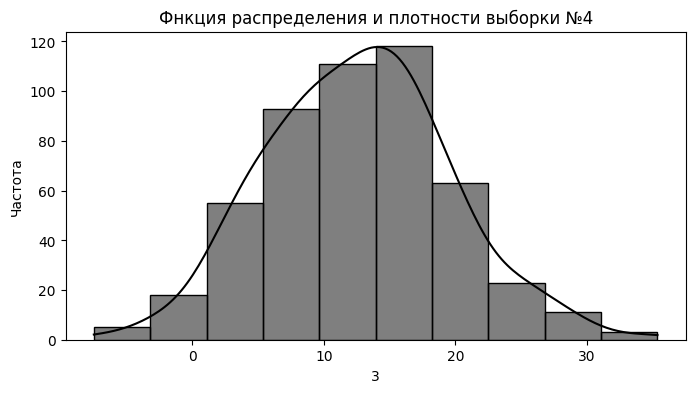

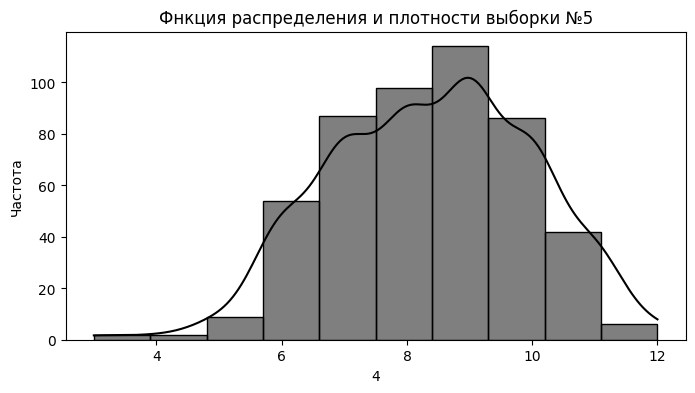

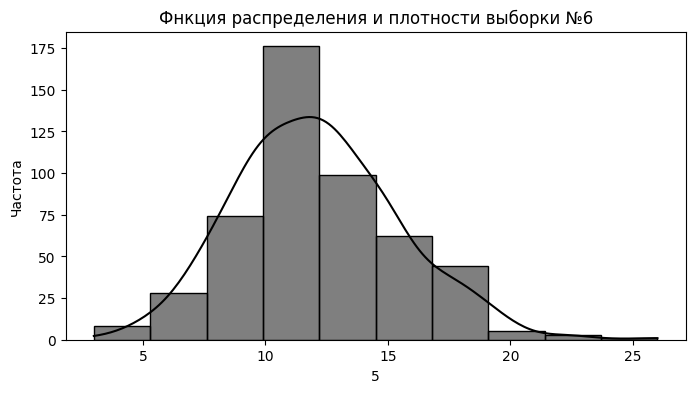

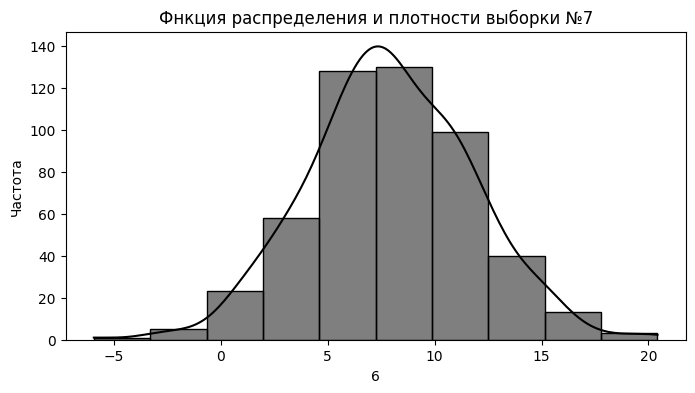

In [88]:
for col in df.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True, bins=10, color="black")
    plt.title(f"Фнкция распределения и плотности выборки №{col + 1}")
    plt.xlabel(col)
    plt.ylabel("Частота")
    plt.show()

После графического анализа можно сделать пердварительные выводы о распределениях выборок:  
**Выборка №1** Подчиняется законам равномерного распределения  
**Выборка №2 - №6** Подчиняются законам нормального распределения

## 3. Выявление выборосов

### 3.1 Выявление выбросом методом интерквартильного размаха

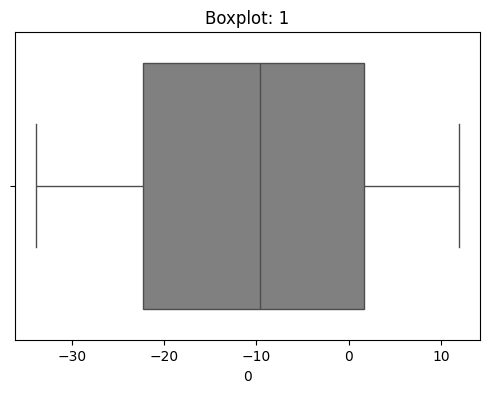

1: 0 выбросов


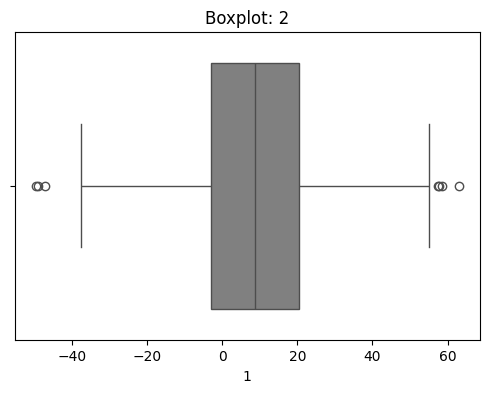

2: 7 выбросов
  Индекс 209: значение 57.35608706343919
  Индекс 300: значение 57.81505446974188
  Индекс 307: значение 58.5615677209571
  Индекс 363: значение -48.87413101643324
  Индекс 369: значение 62.95355401560664
  Индекс 387: значение -47.17097485810518
  Индекс 462: значение -49.50451998412609


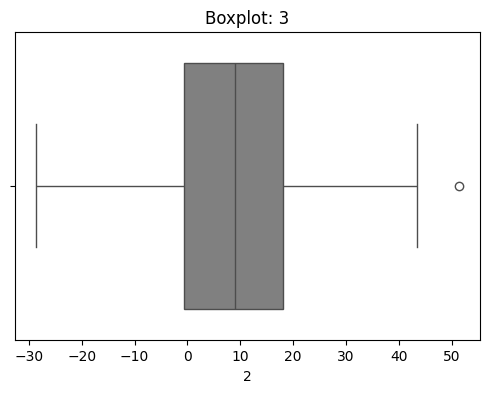

3: 1 выбросов
  Индекс 265: значение 51.36119969189167


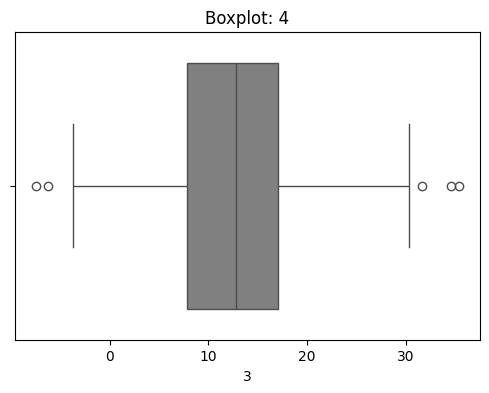

4: 5 выбросов
  Индекс 5: значение 35.343018256127834
  Индекс 37: значение 31.592407625168562
  Индекс 50: значение 34.54033461213112
  Индекс 148: значение -6.227437976747751
  Индекс 258: значение -7.461513147689402


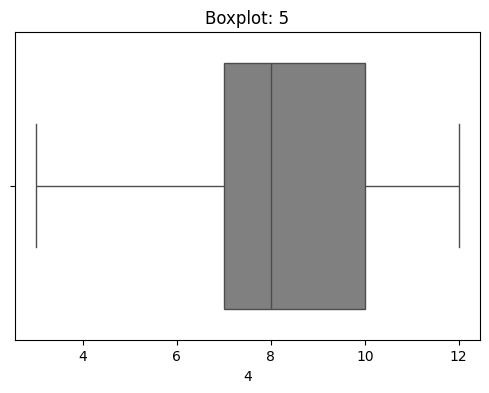

5: 0 выбросов


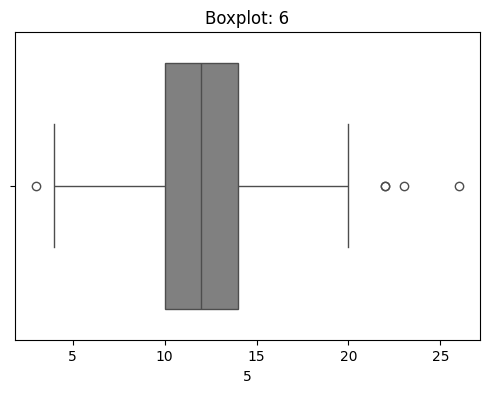

6: 5 выбросов
  Индекс 8: значение 22
  Индекс 69: значение 22
  Индекс 146: значение 26
  Индекс 322: значение 23
  Индекс 381: значение 3


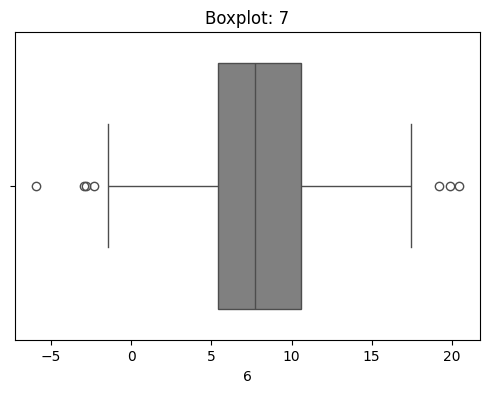

7: 7 выбросов
  Индекс 0: значение -2.336079867556691
  Индекс 97: значение 19.874944902956486
  Индекс 118: значение -2.8429230749607086
  Индекс 179: значение 20.426753528416157
  Индекс 238: значение -2.955554898828268
  Индекс 288: значение -5.9488838613033295
  Индекс 448: значение 19.18052750825882


In [106]:
for col in df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], color="grey")
    plt.title(f"Boxplot: {col + 1}")
    plt.show()

    outliers_dict = {}
    
    data = df[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    
    outliers_dict[col] = outliers.to_dict()
    
    print(f"{col + 1}: {len(outliers)} выбросов")
    for idx, val in outliers_dict[col].items():
        print(f"  Индекс {idx}: значение {val}")

### 3.2 Выявление выбросов при помощи критерия Рознера

Критерий Рознера - модифицированная версия критерия Граббса, которая ищет больше чем один выброс на выборке, подчиненной нормальному распределению

Критерий Рознера: $$R_i = \frac{|x_i - \bar{x}|}{s}$$


Критическое значение критерия Рознера: $$
\lambda_i =
\frac{(n-i) \, t_{p,n-i-1}}
{\sqrt{(n-i-1 + t_{p,n-i-1}^2)(n-i+1)}}
$$

In [86]:
def rosner_test(data, max_outliers=7, alpha=0.05):

    data = data.dropna()
    n = len(data)
    temp_data = data.copy()
    outliers_idx = []

    for i in range(1, max_outliers + 1):
        mean = temp_data.mean()
        std = temp_data.std(ddof=1)
        deviations = abs(temp_data - mean)
        R_i = deviations.max() / std
        idx_max = deviations.idxmax()

        p = 1 - alpha / (2*(n - i + 1))
        t_crit = stats.t.ppf(p, df=n-i-1)
        lambda_crit = ((n - i) * t_crit) / np.sqrt((n-i-1 + t_crit**2) * (n - i + 1))

        if R_i > lambda_crit:
            outliers_idx.append(idx_max)
            temp_data = temp_data.drop(idx_max)
        else:
            break

    return outliers_idx


In [90]:
for col in df.columns:
    if col + 1 == 1:
        print('1: Равномерное распределение')
        continue
    outliers_col = rosner_test(df[col])
    print(f"{col + 1}: выбросов по критерию Рознера:", len(outliers_col))

1: Равномерное распределение
2: выбросов по критерию Рознера: 0
3: выбросов по критерию Рознера: 0
4: выбросов по критерию Рознера: 0
5: выбросов по критерию Рознера: 0
6: выбросов по критерию Рознера: 1
7: выбросов по критерию Рознера: 0


## 4. Замена выбросов при помощи винзоризации

$$
x_{\text{замена}} =
\begin{cases}
\mu - 3\sigma, & x < \mu - 3\sigma \\
\mu + 3\sigma, & x > \mu + 3\sigma \\
x, & \text{иначе}
\end{cases}
$$

In [93]:
df_copy = df.copy()

outliers_info = {}

for col in df_copy.select_dtypes(include=np.number).columns:
    
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_mask = (df_copy[col] < lower_bound) | (df_copy[col] > upper_bound)
    outliers_info[col] = df_copy.loc[outliers_mask, col]
    
    df_copy[col] = np.where(df_copy[col] < lower_bound,
                             lower_bound,
                             np.where(df_copy[col] > upper_bound,
                                      upper_bound,
                                      df_copy[col]))

for col, values in outliers_info.items():
    print(f"{col}: заменено {len(values)} значений")

0: заменено 0 значений
1: заменено 7 значений
2: заменено 1 значений
3: заменено 5 значений
4: заменено 0 значений
5: заменено 5 значений
6: заменено 7 значений


Проверим корректность замены выбросов при помощи метода межквартильного размаха

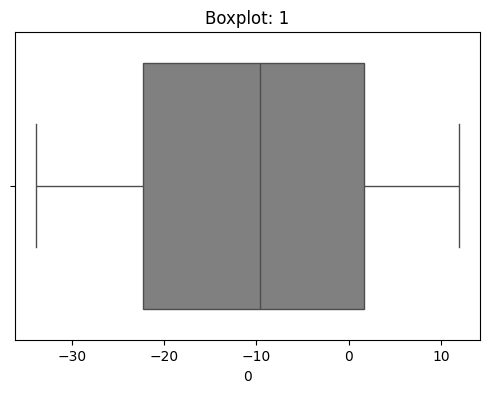

1: 0 выбросов


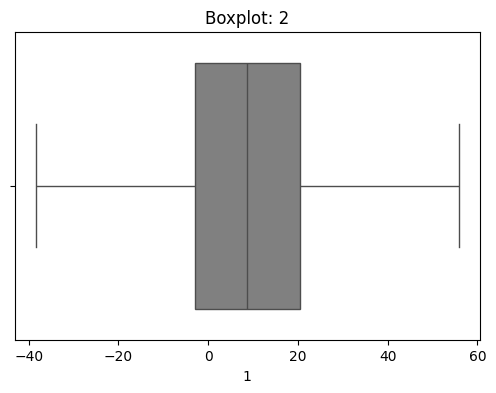

2: 0 выбросов


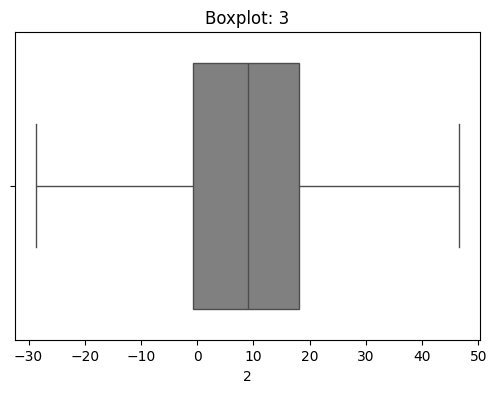

3: 0 выбросов


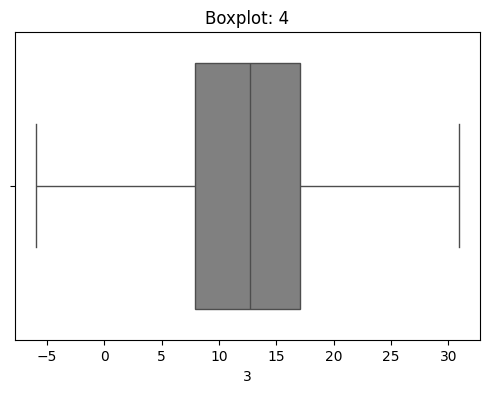

4: 0 выбросов


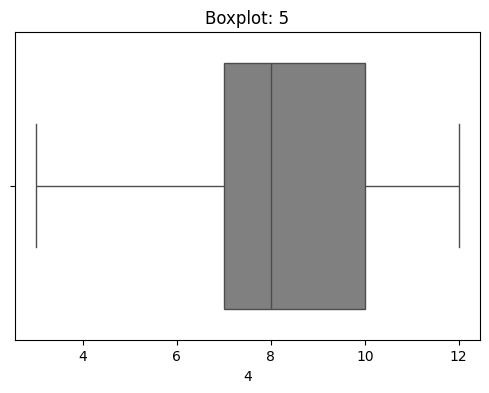

5: 0 выбросов


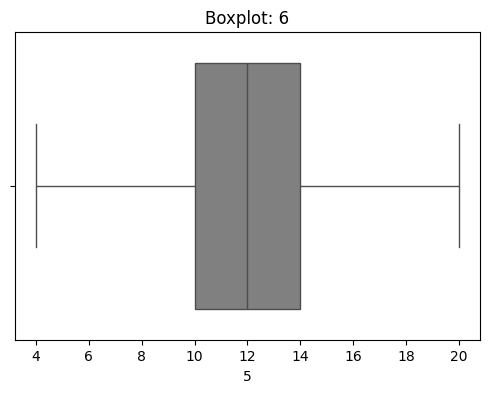

6: 0 выбросов


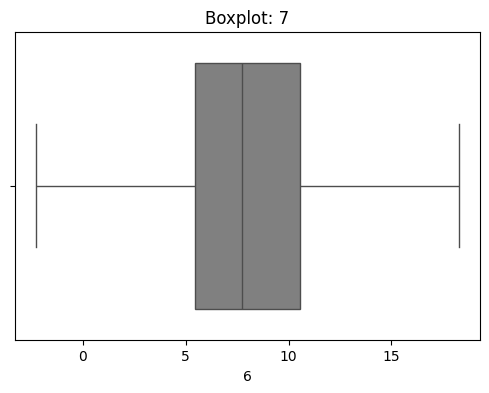

7: 0 выбросов


In [104]:
for col in df_copy.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_copy[col], color="grey")
    plt.title(f"Boxplot: {col + 1}")
    plt.show()

    outliers_dict = {}
    
    data = df_copy[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    
    outliers_dict[col] = outliers.to_dict()
    
    print(f"{col + 1}: {len(outliers)} выбросов")
    for idx, val in outliers_dict[col].items():
        print(f"  Индекс {idx}: значение {val}")

Как видно из боксплотов, выбросы были заменены корректно

## 5. Сохраняем обновленный датасет

In [105]:
output_file = "reworked_data.xlsx"
df_clean.to_excel(output_file, index=False)

## 6. Выводы

1. На основе оценки числовых характеристик и графического анализа можно сделать вывод о распределениях выборок:
- Выборка №1 - Равномерное распределение.
- Выборки №2 - №5 - Биноминальное распределение
- Выборка №6 - Пуассоновское распределение
2. В качестве оценки выборсов на выборках были применены два метода - метод интерквартильного размаха и метод, основанный на критерии Рознера:
    Критерием Рознера получилось оценить только 5 выборок, так как первая распределена равномерно, что делает ее оценку критерием Рознера недопустимой.
    Межквартильный размах выявил 25 выбросов, в то время как критерий Розберга только 1.
3. Выявленные IQR выбросы были заменены на ближайшую допустимую границу (Метод винзоризации) этот метод был выбран так как про предварительной оценке, все выборки кроме первой распределены в соответствии с нормальным распределением, и так как в первой выборке не было выявленных выбросов, был выбран метод, который сохраняет форму ннрмального распределения и минимально изменяет статистические значения.
4. В ходе работы были сделаны предварительные заключения о законах распределения СВ, выявлены и заменены выбросы, обработанный датасет находится в таблице "reworked_data.xlsx"